In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os #run this if running on a remote server!

os.environ['QT_QPA_PLATFORM'] = 'offscreen'

In [33]:
import sys
sys.path.append('../')
from utility.file_utility import FileUtility

# Running DiMotif step-by-step

<img src="../DiMotif.pdf">

Files containing positive and negative sequences (a sequence per line)

In [23]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

#input max number of clusters here
def cluster_splitting(df_str = '~/src/Ferredoxin_Unsupervised_Learning/data/foldseek_umap_clusters.csv', train_prop = 0.8, path = "../datasets/PPE_input_datasets/"):
    
    df = pd.read_csv(df_str)

    cluster_num = df['cluster'].nunique()

    for i in range(cluster_num):

        folder_path = os.path.join(path, "cluster_" + str(i) + "/")

        try:
            # os.makedirs with exist_ok=True will not raise an error if the folder exists
            os.makedirs(folder_path, exist_ok=True)
            print(f"Folder ready at: {os.path.abspath(folder_path)}")
        except OSError as e:
            print(f"Error creating folder '{folder_path}': {e}")

        unique_rows_df = df.drop_duplicates(subset=['protein_ID'])
    
        #filter based on cluster number
        cluster = unique_rows_df[unique_rows_df['cluster'] == i]
        notcluster = unique_rows_df[unique_rows_df['cluster'] != i]
        
        #sample cluster subset based on given percentage
        cluster_train_df = cluster.sample(frac=train_prop, random_state=42)
        cluster_test_df = cluster.drop(cluster_train_df.index)
    
        #sample non-cluster subset based on given percentage
        notcluster_train_df = notcluster.sample(frac=train_prop, random_state=42)
        notcluster_test_df = notcluster.drop(notcluster_train_df.index)
    
        #write out cluster as fasta
            #train
        with open(os.path.join(folder_path, "pos_train_cluster_" + str(i)) + '.txt', "w") as f:
            for index, row in cluster_train_df.iterrows():
                f.write(f">{row['protein_ID']}\n{row['qseq']}\n")
            #test
        with open(os.path.join(folder_path, "pos_test_cluster_" + str(i)) + '.txt', "w") as f:
            for index, row in cluster_test_df.iterrows():
                f.write(f">{row['protein_ID']}\n{row['qseq']}\n")
        
        #write out non-cluster as fasta
        with open(os.path.join(folder_path + "neg_train_cluster_" + str(i)) + '.txt', "w") as f:
            for index, row in notcluster_train_df.iterrows():
                f.write(f">{row['protein_ID']}\n{row['qseq']}\n")
            #test
        with open(os.path.join(folder_path + "neg_test_cluster_" + str(i)) + '.txt', "w") as f:
            for index, row in notcluster_test_df.iterrows():
                f.write(f">{row['protein_ID']}\n{row['qseq']}\n")
    print('complete')

In [24]:
cluster_splitting()

Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_0
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_1
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_2
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_3
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_4
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_5
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_6
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_7
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_8
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_9
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_10
Folder ready at: /home/ss307/src/dimotif/datasets/PPE_input_datasets/cluster_11
complete


In [25]:
import os

def read_in_cluster_training(cluster_num):

    file_path = '../datasets/PPE_input_datasets/'
    cluster_num = 'cluster_' + str(cluster_num)

    # training file
    pos_train_file= os.path.join(file_path, cluster_num, 'pos_train_' +  cluster_num + '.txt')
    neg_train_file= os.path.join(file_path, cluster_num,'neg_train_' + cluster_num + '.txt')

    # testing file
    pos_test_file= os.path.join(file_path, cluster_num,'pos_test_' + cluster_num + '.txt')
    neg_test_file= os.path.join(file_path, cluster_num, 'neg_train_' + cluster_num + '.txt')


    return pos_train_file, neg_train_file, pos_test_file, neg_test_file

In [26]:
pos_train_file, neg_train_file, pos_test_file, neg_test_file = read_in_cluster_training(1)

In [27]:
# load positive and negative sequences
pos_seqs=FileUtility.load_list(pos_train_file)
neg_seqs=FileUtility.load_list(neg_train_file)

# prepare labels and sequences
seqs=[seq.lower() for seq in pos_seqs+neg_seqs]
labels=[1]*len(pos_seqs)+[0]*len(neg_seqs)

## (i) Sequence segmentation

The segmentation can be applied based on the segmentation learned from Swiss-Prot database (general-purpose) or from the positive set (domain-specific)

### Loading Swiss-Prot Segmentation

We need to load the alpha distribution for segmentation sampling from the file.

In [28]:
import scipy.stats as st
import numpy as np
import tqdm
from utility.math_utility import normalize_mat


swiss_size_change=FileUtility.load_obj('../data_config/swiss_1000_samples.pickle')
all_samples=[]
for i in tqdm.tqdm(range(0,1000)):
    sample=[]
    for vocab in np.arange(10000,1000000,10000):
        sample.append(swiss_size_change[vocab][i])
    all_samples.append(-np.diff(sample))

sample_mat=np.mean(normalize_mat(all_samples),axis=0)
sample_mat_std=np.std(normalize_mat(all_samples),axis=0)
alpha_param = st.alpha.fit(sample_mat)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 68620.72it/s]


Then we sample from the alpha distribution:

In [29]:
# number of segmentation to be used

segmentation_schemes=10
r = st.alpha.rvs(alpha_param[0], size=segmentation_schemes)
vocab_sizes=np.array(np.round(10000+(r*10000)),dtype=np.int32).tolist()
vocab_sizes.sort()

In [13]:
# vocabulary sizes seen from Swiss-Prot
vocab_sizes

[13947, 14296, 14756, 16091, 18058, 18569, 26281, 27118, 27719, 35123]

# In this step we perform segmentation of the ferredoxin sequences based on the steps we have trained already on Swiss-Prot

In [30]:
from make_representations.cpe_apply import CPE

segmented_seqs=[]
for i, vocab in tqdm.tqdm(enumerate(vocab_sizes)):
    f=open('../data_config/swissprot_ppe','r')
    CPE_Applier=CPE(f,separator='', merge_size=vocab)
    for idx, seq in enumerate(seqs):
        if i ==0:
            segmented_seqs.append([CPE_Applier.segment(seq)])
        else:
            segmented_seqs[idx]+=[CPE_Applier.segment(seq)]
extended_sequences=[' '.join(l) for l in segmented_seqs]
possible_segmentations=['@@@'.join(l) for l in segmented_seqs]

10it [02:44, 16.46s/it]


We pick the SWISS-Prot segmentation for the next steps.

## (ii) Discriminative Motif discovery

Using Chi-square test we find the most significant motifs related to the positive class

In [36]:
from chi2analysis.chi2analysis import Chi2Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

# top 50 motifs
topn=50

cpe_vectorizer = TfidfVectorizer(use_idf=False, analyzer='word',
                                              norm=None, stop_words=[], lowercase=True, binary=False, tokenizer=str.split)

tf_vec=cpe_vectorizer.fit_transform(extended_sequences)
vocab=cpe_vectorizer.get_feature_names_out()
CH=Chi2Analysis(tf_vec,labels,vocab)
vocab_binary=[(x[0],x[2]) for x in CH.extract_features_fdr('../datasets/'+'/motifs.txt',
                                                           N=topn, alpha=5e-2, 
                                                           direction=False,
                                                           allow_subseq=False,
                                                           binarization=True,
                                                           remove_redundant_markers=False) if x[1]>0]


/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [37]:
print ('motif','\t', 'p-value')
print ('=====================')
for motif, pval in vocab_binary:
    print (motif,'\t', pval)

motif 	 p-value
cac 	 0.0
dk 	 0.0
aw 	 0.0
ace 	 0.0
tin 	 0.0
ky 	 0.0
tt 	 0.0
ph 	 0.0
ip 	 0.0
glep 	 0.0
ipky 	 0.0
mldk 	 0.0
peg 	 0.0
ieh 	 0.0
vreg 	 0.0
vve 	 0.0
h 	 0.0
gle 	 0.0
cpeg 	 0.0
ks 	 0.0
ieie 	 0.0
cq 	 0.0
slee 	 0.0
hak 	 0.0
draw 	 0.0
en 	 0.0
cpdg 	 0.0
ch 	 0.0
slne 	 0.0
mp 	 0.0
hac 	 0.0
fd 	 0.0
dll 	 0.0
vlph 	 0.0
nh 	 0.0
ireg 	 0.0
rls 	 0.0
dedl 	 0.0
acgg 	 0.0
flp 	 0.0
pes 	 0.0
ice 	 0.0
kys 	 0.0
cp 	 0.0
lldk 	 0.0
avle 	 0.0
hare 	 0.0
vi 	 0.0
adel 	 0.0
qiv 	 1.0630610892539355e-308


## (iii)  Motif visualizations

### Co-occurrences of motifs

Then we look at the co-occurrences pattern of the motifs on the positive set

In [38]:
from utility.math_utility import get_sym_kl_rows
from clustering.hierarchical import HierarchicalClutering
import numpy as np

idxs = np.array([np.where(vocab == v[0])[0][0] for v in vocab_binary])
pos_matrix=tf_vec.toarray()[0:len(pos_seqs),idxs]

# it saves the co-occurance matrix in the output directory and sym_KL.pickle
DIST=get_sym_kl_rows(pos_matrix.T)
FileUtility.save_obj('../datasets/'+'/sym_KL', DIST)

/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/scipy/cluster/hierarchy.py:326: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='complete', metric='euclidean')


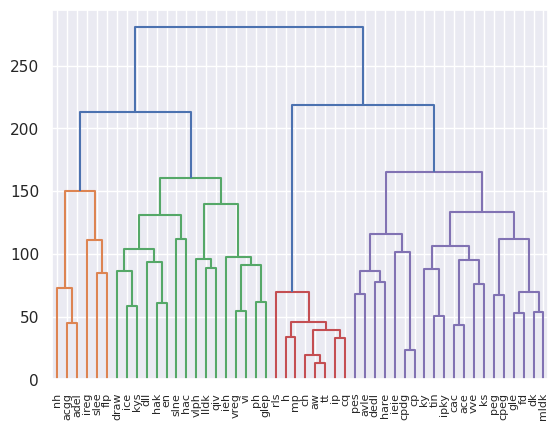

In [41]:
HC=HierarchicalClutering(DIST,[x[0] for x in vocab_binary])
motifs=vocab_binary
tree=HC.nwk

In [38]:
# tree of motifs
HC.nwk

'((((((((((((prs:86.24,vctt:86.24):10.24,yvll:96.48):17.64,pss:114.12):9.44,dal:123.56):23.46,(irlp:95.88,qse:95.88):51.14):25.92,((((pc:43.34,ngtc:43.34):33.97,kaeg:77.31):12.93,wil:90.24):8.38,glsr:98.62):74.33):33.59,((((((ss:83.88,acss:83.88):38.03,aee:121.91):2.35,((sgs:109.29,ty:109.29):9.09,qsfl:118.38):5.88):16.33,((vpd:82.87,yil:82.87):23.16,(dc:62.73,pts:62.73):43.30):34.57):17.93,((ikth:90.41,fld:90.41):14.48,((yqv:69.34,cvg:69.34):15.99,fall:85.32):19.57):53.63):11.12,((((vvie:83.55,wvl:83.55):11.65,(ags:50.18,css:50.18):45.02):10.17,kee:105.37):11.43,fgl:116.81):52.83):36.89):24.42,((((fs:87.98,ile:87.98):16.93,caa:104.91):30.60,ddd:135.50):22.33,(agl:127.93,qg:127.93):29.91):73.11):6.12,(((((((dede:23.69,vyel:23.69):14.19,cav:37.88):13.40,fgkg:51.29):11.25,qfg:62.54):5.85,qpe:68.39):14.95,(yall:57.55,cvs:57.55):25.79):41.17,(yprs:72.62,pfs:72.62):51.89):112.55):33.05,((((til:63.41,ytve:63.41):7.80,(((((fvg:12.99,iaqe:12.99):3.65,mcl:16.65):15.11,qpaa:31.76):4.99,kyp:36.75

### Visualization of co-occurence pattern

In [39]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def create_mat_plot(
    mat,
    axis_names,
    title,
    filename,
    xlab,
    ylab,
    cmap="Blues",
    filetype=".png",
    rx=0,
    ry=0,
    font_s=10,
    annot=True,
):
    """Generates and saves a heatmap for 1D or 2D NumPy arrays without system TeX/dvipng dependencies."""
    # Ensure Matplotlib uses internal rendering (no external TeX/dvipng required)
    plt.rcParams["text.usetex"] = False

    # Convert 1D array to a 2D row matrix (1, N) for Seaborn
    mat = np.atleast_2d(mat)

    plt.figure()

    # Handle tick labels based on matrix dimensions
    if len(axis_names) > 0:
        xtick_labels = (
            axis_names if mat.shape[1] == len(axis_names) else "auto"
        )
        ytick_labels = (
            axis_names if mat.shape[0] == len(axis_names) else False
        )

        ax = sns.heatmap(
            mat,
            annot=annot,
            cmap=cmap,
            xticklabels=xtick_labels,
            yticklabels=ytick_labels,
        )
    else:
        ax = sns.heatmap(mat, annot=annot, cmap=cmap)

    # Set labels and title
    plt.title(title, fontsize=font_s)
    plt.xlabel(xlab, fontsize=font_s)
    plt.ylabel(ylab, fontsize=font_s)

    # Adjust tick font size and rotation
    plt.xticks(fontsize=font_s, rotation=rx)
    plt.yticks(fontsize=font_s, rotation=ry)

    # Save figure
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{filename}.{filetype}", bbox_inches="tight")
    plt.close()

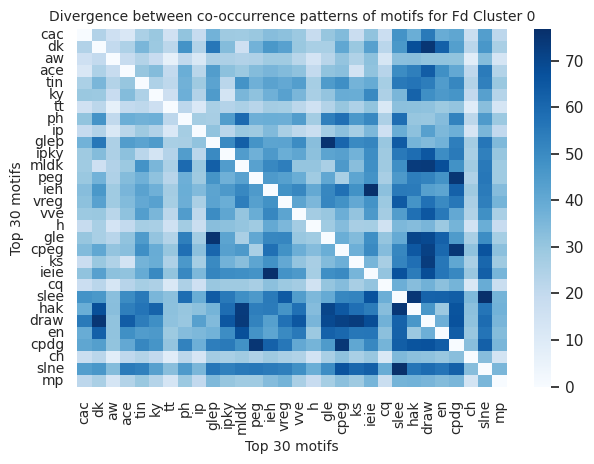

In [42]:
create_mat_plot(DIST[0:30,0:30], [x[0] for x in motifs[0:30]],'Divergence between co-occurrence patterns of motifs for Fd Cluster 0','Biofilm formation','Top 30 motifs','Top 30 motifs',annot=False, rx=90)

## Adding annotations related to secondary structure and other properties

In [43]:
from proteinseq_util.motif_properties import MotifProperties

In [44]:
MotifPropVis=MotifProperties()

In [ ]:
# get most probable structure of this motif in the PDB sequences
MotifPropVis.getMotifStructure('mgl')
#H = alpha helix
#B = residue in isolated beta-bridge
#E = extended strand, participates in beta ladder
#G = 3-helix (3/10 helix)
#I = 5 helix (pi helix)
#T = hydrogen bonded turn
#S = bend
#N = loop or other irregular structure

In [34]:
sec_classes,prop=MotifPropVis.get_motifs_pss_biophys(['mgl'])

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 9078.58it/s]


In [35]:
prop
# The order is the normalized
#['mean_molecular_weight',
# 'mean_flexibility',
# 'instability',
# 'mean_surface_accessibility',
# 'mean_kd_hydrophobicity',
# 'mean_hydrophilicity']

{'mgl': [-1.0114634864612668,
  np.float64(-0.28252406036752725),
  np.float64(-0.28258896805474465),
  np.float64(-0.970740175139044),
  np.float64(0.7751299216012043),
  np.float64(-0.4360941592403529)]}

#### if you have ete3 installed you can get the tree visualization as well

In [45]:
from proteinseq_util.motif_tree_visualization import VisualizeTreeOfMotifs

In [46]:
VT=VisualizeTreeOfMotifs(tree,[x[0] for x in motifs])

VT.create_circle('../datasets/'+'/biofilm_prop.pdf', 'BioFilm tree of motifs', ignore_branch_length=True)

  0%|                                                                                            | 0/50 [00:00<?, ?it/s]/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 31808.77it/s]


<img src="biofilm_prop.pdf">